cargo las librerias

In [6]:
import geopandas as gpd
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt


Leemos el vector, e imprimimos primeras filas (ver si sigue siendo necesario, ya que se aplico el vector a las bandas en el archivo multibandas; lo mantengo por si se necesita utilizar para otra cosa)

In [7]:
ruta_vector = "../vectores/area_de_estudio_utm.gpkg"
vector = gpd.read_file(ruta_vector)

print(vector.head())
print("¡Vector cargado con éxito!")
print(vector.crs) 

                                            geometry
0  POLYGON ((313025.844 -3042727.439, 312931.204 ...
¡Vector cargado con éxito!
EPSG:32621


Lectura del raster. Abrimos el archivo con rasterio. Se abre directamente el archivo multibandas de la fecha estudiada. No se considero la banda 10 por ser infrarrojo TERMICO, VER!!!!

In [8]:
ruta_multibanda = "../multibandas/20260125.tif"

with rio.open(ruta_multibanda) as src:
    print("¡Archivo multibanda abierto con éxito!")
    print("Número de bandas (capas) disponibles:", src.count)
    print("Dimensiones de las matrices:", src.width, "x", src.height)
    print("Sistema de coordenadas:", src.crs)

¡Archivo multibanda abierto con éxito!
Número de bandas (capas) disponibles: 7
Dimensiones de las matrices: 204 x 211
Sistema de coordenadas: EPSG:32621


Calculo indice MNDWI

In [9]:
# 1. Extraemos la banda Verde (capa 3) y SWIR1 (capa 6) directamente del archivo multibanda
with rio.open(ruta_multibanda) as src:
    verde = src.read(3).astype(np.float32)
    swir1 = src.read(6).astype(np.float32)

# 2. Reemplazamos los ceros por NaN (valores nulos) para evitar divisiones inválidas
verde[verde == 0] = np.nan
swir1[swir1 == 0] = np.nan

# 3. Calculamos el índice MNDWI ignorando advertencias matemáticas (nanmin y nanmax para que ignore los espacios vacíos y nos muestre los números reales)
with np.errstate(divide='ignore', invalid='ignore'):
    mndwi = (verde - swir1) / (verde + swir1)

print("¡Índice MNDWI calculado con éxito desde el multibanda unificado!")
print("Valor mínimo:", np.nanmin(mndwi))
print("Valor máximo:", np.nanmax(mndwi))

¡Índice MNDWI calculado con éxito desde el multibanda unificado!
Valor mínimo: -0.33029056
Valor máximo: 0.23048888


Calculo del promedio del MNDWI como limitante de la mascara de agua, donde asigno 1 al agua y 0 a lo que no sea agua. Luego grafico la mascara de agua

El umbral calculado (Promedio del MNDWI) es: -0.0341


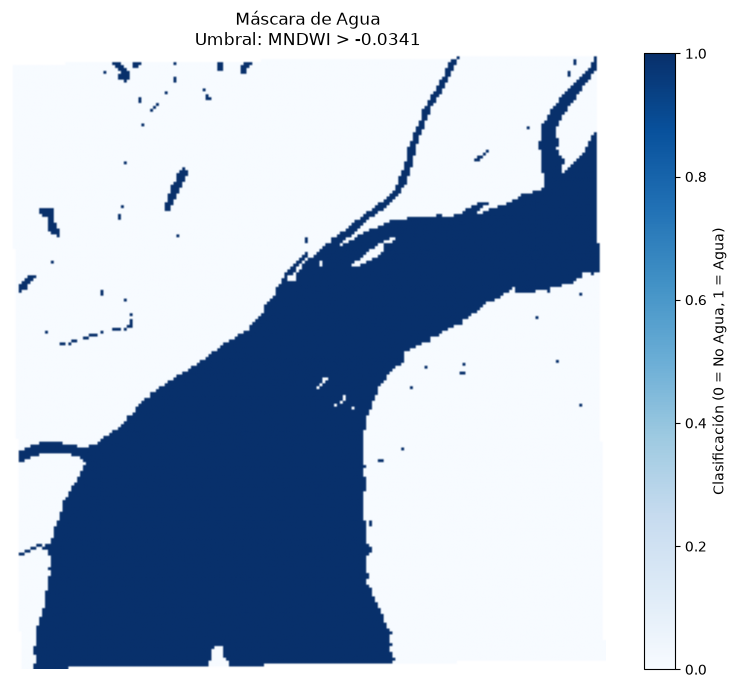

In [10]:
# 1. Calculamos el promedio del MNDWI ignorando los valores nulos (NaN)
umbral_promedio = np.nanmean(mndwi)
print(f"El umbral calculado (Promedio del MNDWI) es: {umbral_promedio:.4f}")

# 2. Creamos la máscara de agua: 
# Si el píxel es mayor al promedio será 1 (Agua), sino será 0 (No agua).
mascara_agua = np.where(mndwi > umbral_promedio, 1, 0).astype(float)

# (Opcional) Volvemos a poner NaN en los bordes fuera de la cuenca para que el gráfico quede limpio (PREGUNTAR!!!)
mascara_agua[np.isnan(mndwi)] = np.nan

# 3. Graficamos la máscara resultante
plt.figure(figsize=(10, 8))
# Usamos un mapa de colores donde el 1 se vea azul y el 0 más claro
im = plt.imshow(mascara_agua, cmap='Blues') 
plt.colorbar(im, label='Clasificación (0 = No Agua, 1 = Agua)')
plt.title(f'Máscara de Agua\nUmbral: MNDWI > {umbral_promedio:.4f}')
plt.axis('off')
plt.show()

Abro el archivo multibandas y lo paso a decimales (necesario para tener precision para el calculo de la reflanctancia posteriormente)

In [11]:
ruta_multibanda = "../multibandas/20260125.tif"

with rio.open(ruta_multibanda) as src:
    bandas_dn = src.read().astype(np.float32)

print("¡Bandas DN leídas con éxito!")
print(f"Dimensiones del cubo original (bandas, alto, ancho): {bandas_dn.shape}")

¡Bandas DN leídas con éxito!
Dimensiones del cubo original (bandas, alto, ancho): (7, 211, 204)


Aplico la matriz binaria mascara_agua sobre todo el cubo de bandas en formato DN, convirtiendo en NaN (nulo) todo aquello que pertenezca a la tierra o la vegetación para no procesar información innecesaria.

In [12]:
# Creamos una copia para trabajar de forma segura
bandas_dn_enmascaradas = np.copy(bandas_dn)

# Recorremos cada banda (capa) y filtramos usando la máscara de agua
for i in range(bandas_dn_enmascaradas.shape[0]):
    bandas_dn_enmascaradas[i][mascara_agua != 1] = np.nan

print("¡Máscara de agua aplicada con éxito sobre los Números Digitales!")

¡Máscara de agua aplicada con éxito sobre los Números Digitales!


Aplico la formula correspondiente a Landsat para corregir los valores a reflactancia de superficie

In [13]:
# Tratamos posibles ceros remanentes para evitar conflictos matemáticos
bandas_dn_enmascaradas[bandas_dn_enmascaradas == 0] = np.nan

# Aplicamos la fórmula de conversión oficial
bandas_ref_agua = (bandas_dn_enmascaradas * 0.0000275) - 0.2

print("¡Conversión a reflectancia completada con éxito!")
print(f"Dimensiones del cubo final de agua: {bandas_ref_agua.shape}")

¡Conversión a reflectancia completada con éxito!
Dimensiones del cubo final de agua: (7, 211, 204)
